<a href="https://colab.research.google.com/github/Hertfordshire-Data-Science-Hackathon/Group-F-RMDS-Hackathon/blob/main/Copy_of_hackathon_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# SECTION 1 — Install & Import

In [2]:
# Install any packages
!pip install xgboost lightgbm shap optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.1 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

#  Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

#  Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score
)

#  Models
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

#  Explainability
import shap

#  Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('All libraries loaded successfully!')

All libraries loaded successfully!


---
#  SECTION 2 — Load Data

In [5]:
df_train = pd.read_csv('dataset_A_training.csv')
df_test  = pd.read_csv('dataset_A_testing.csv')

Target_variable = 'seasonal_variable'

print(f'Train shape: {df_train.shape}')
print(f'Test shape:  {df_test.shape}')
print(f'Target:  {Target_variable}')
df_train.head()

Train shape: (4756, 31)
Test shape:  (4749, 30)
Target:  seasonal_variable


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Male,NaN,Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,education,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,Male,"> $75,000",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,0
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,utilities,1
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",2.0,0.0,NaN,0


---
#  SECTION 3 — Exploratory Data Analysis (EDA)


In [6]:
#  3.1 Basic Info
print('='*60)
print('DATASET OVERVIEW')
print('='*60)
print(f'Rows: {df_train.shape[0]:,}  |  Columns: {df_train.shape[1]}')
print()
print('Data Types:')
print(df_train.dtypes.value_counts())
print()
df_train.info()

DATASET OVERVIEW
Rows: 4,756  |  Columns: 31

Data Types:
float64    19
object     10
int64       2
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   flu_concern                  4744 non-null   float64
 2   flu_knowledge                4733 non-null   float64
 3   behavioral_antiviral_meds    4742 non-null   float64
 4   behavioral_avoidance         4724 non-null   float64
 5   behavioral_face_mask         4753 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4747 non-null   float64
 9   behavioral_touch_face        4737 non-null   float64
 10  doctor_recc_seasonal         4435 non-null   float64
 11  chronic

In [7]:
#  3.2 Statistical Summary
df_train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
respondent_id,4756.0,NaN,NaN,NaN,2378.5,1373.08327,1.0,1189.75,2378.5,3567.25,4756.0
flu_concern,4744.0,NaN,NaN,NaN,1.643128,0.91981,0.0,1.0,2.0,2.0,3.0
flu_knowledge,4733.0,NaN,NaN,NaN,1.293049,0.618902,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,4742.0,NaN,NaN,NaN,0.052299,0.222652,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,4724.0,NaN,NaN,NaN,0.734124,0.441846,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,4753.0,NaN,NaN,NaN,0.073848,0.261551,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,4748.0,NaN,NaN,NaN,0.836563,0.369803,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,4747.0,NaN,NaN,NaN,0.365494,0.481619,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,4747.0,NaN,NaN,NaN,0.336634,0.472608,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,4737.0,NaN,NaN,NaN,0.68841,0.463192,0.0,0.0,1.0,1.0,1.0


 25 columns have missing values:


,Missing Count,Missing %
employment_sector,2314,48.65
health_insurance,1925,40.48
income_poverty,790,16.61
rent_or_own,381,8.01
doctor_recc_seasonal,321,6.75
education,270,5.68
employment_status,269,5.66
marital_status,265,5.57
chronic_med_condition,188,3.95
child_under_6_months,152,3.20


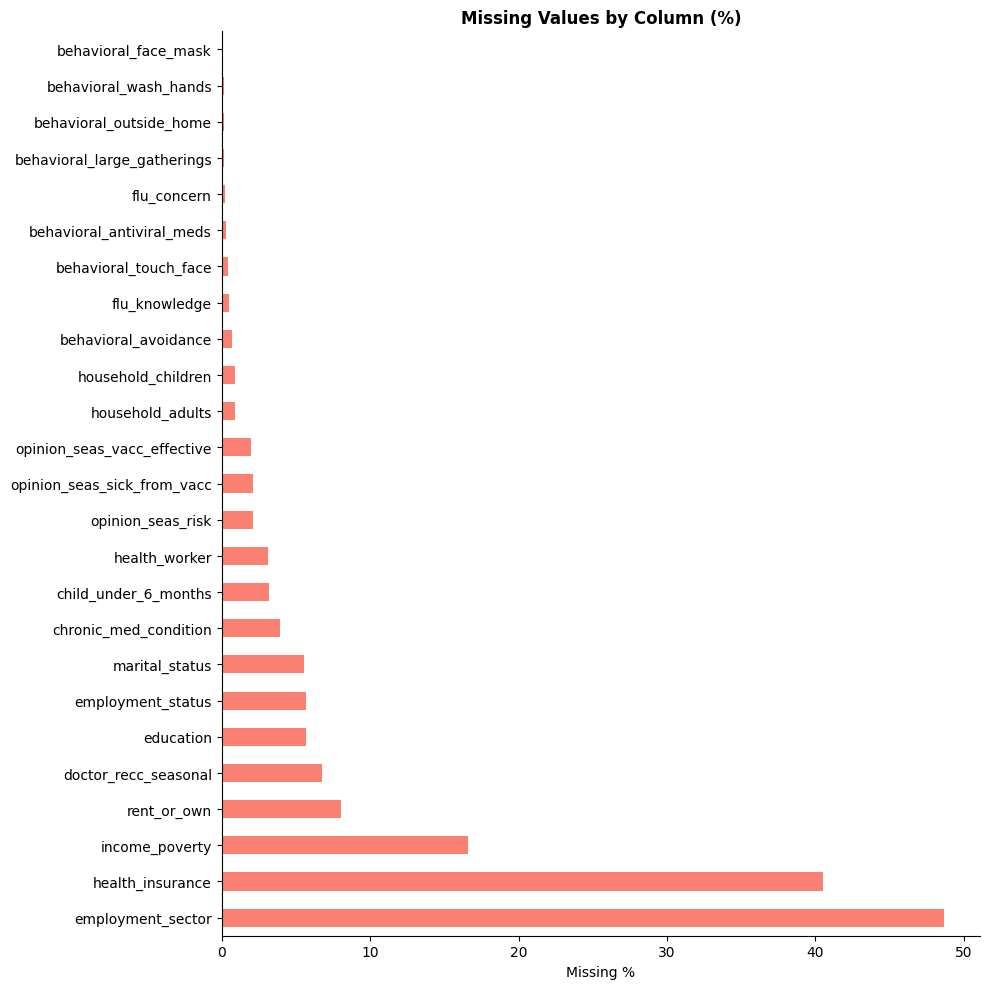

In [8]:
#  3.3 Missing Values
missing = df_train.isnull().sum()
missing_pct = (missing / len(df_train) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if len(missing_df) == 0:
    print('No missing values found!')
else:
    print(f' {len(missing_df)} columns have missing values:')
    display(missing_df)

    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df)*0.4)))
    missing_df['Missing %'].plot(kind='barh', ax=ax, color='salmon')
    ax.set_title('Missing Values by Column (%)', fontweight='bold')
    ax.set_xlabel('Missing %')
    plt.tight_layout()
    plt.show()

 Classes are reasonably balanced (ratio: 1.2x)


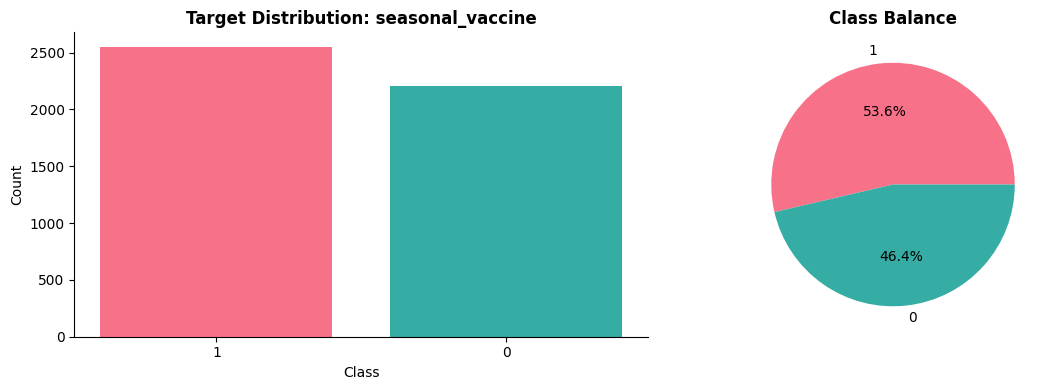

In [9]:
Target_variable = 'seasonal_vaccine'
# 3.4 Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution plot
if df_train[Target_variable].dtype == 'object' or df_train[Target_variable].nunique() < 15:
    # Classification
    counts = df_train[Target_variable].value_counts()
    axes[0].bar(counts.index.astype(str), counts.values, color=sns.color_palette('husl', len(counts)))
    axes[0].set_title(f'Target Distribution: {Target_variable}', fontweight='bold')
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Count')

    axes[1].pie(counts.values, labels=counts.index.astype(str), autopct='%1.1f%%',
                colors=sns.color_palette('husl', len(counts)))
    axes[1].set_title('Class Balance', fontweight='bold')

    # Check imbalance
    imbalance_ratio = counts.max() / counts.min()
    if imbalance_ratio > 3:
        print(f'  Class imbalance detected! Ratio: {imbalance_ratio:.1f}x — consider class_weight="balanced"')
    else:
        print(f' Classes are reasonably balanced (ratio: {imbalance_ratio:.1f}x)')
plt.tight_layout()
plt.show()

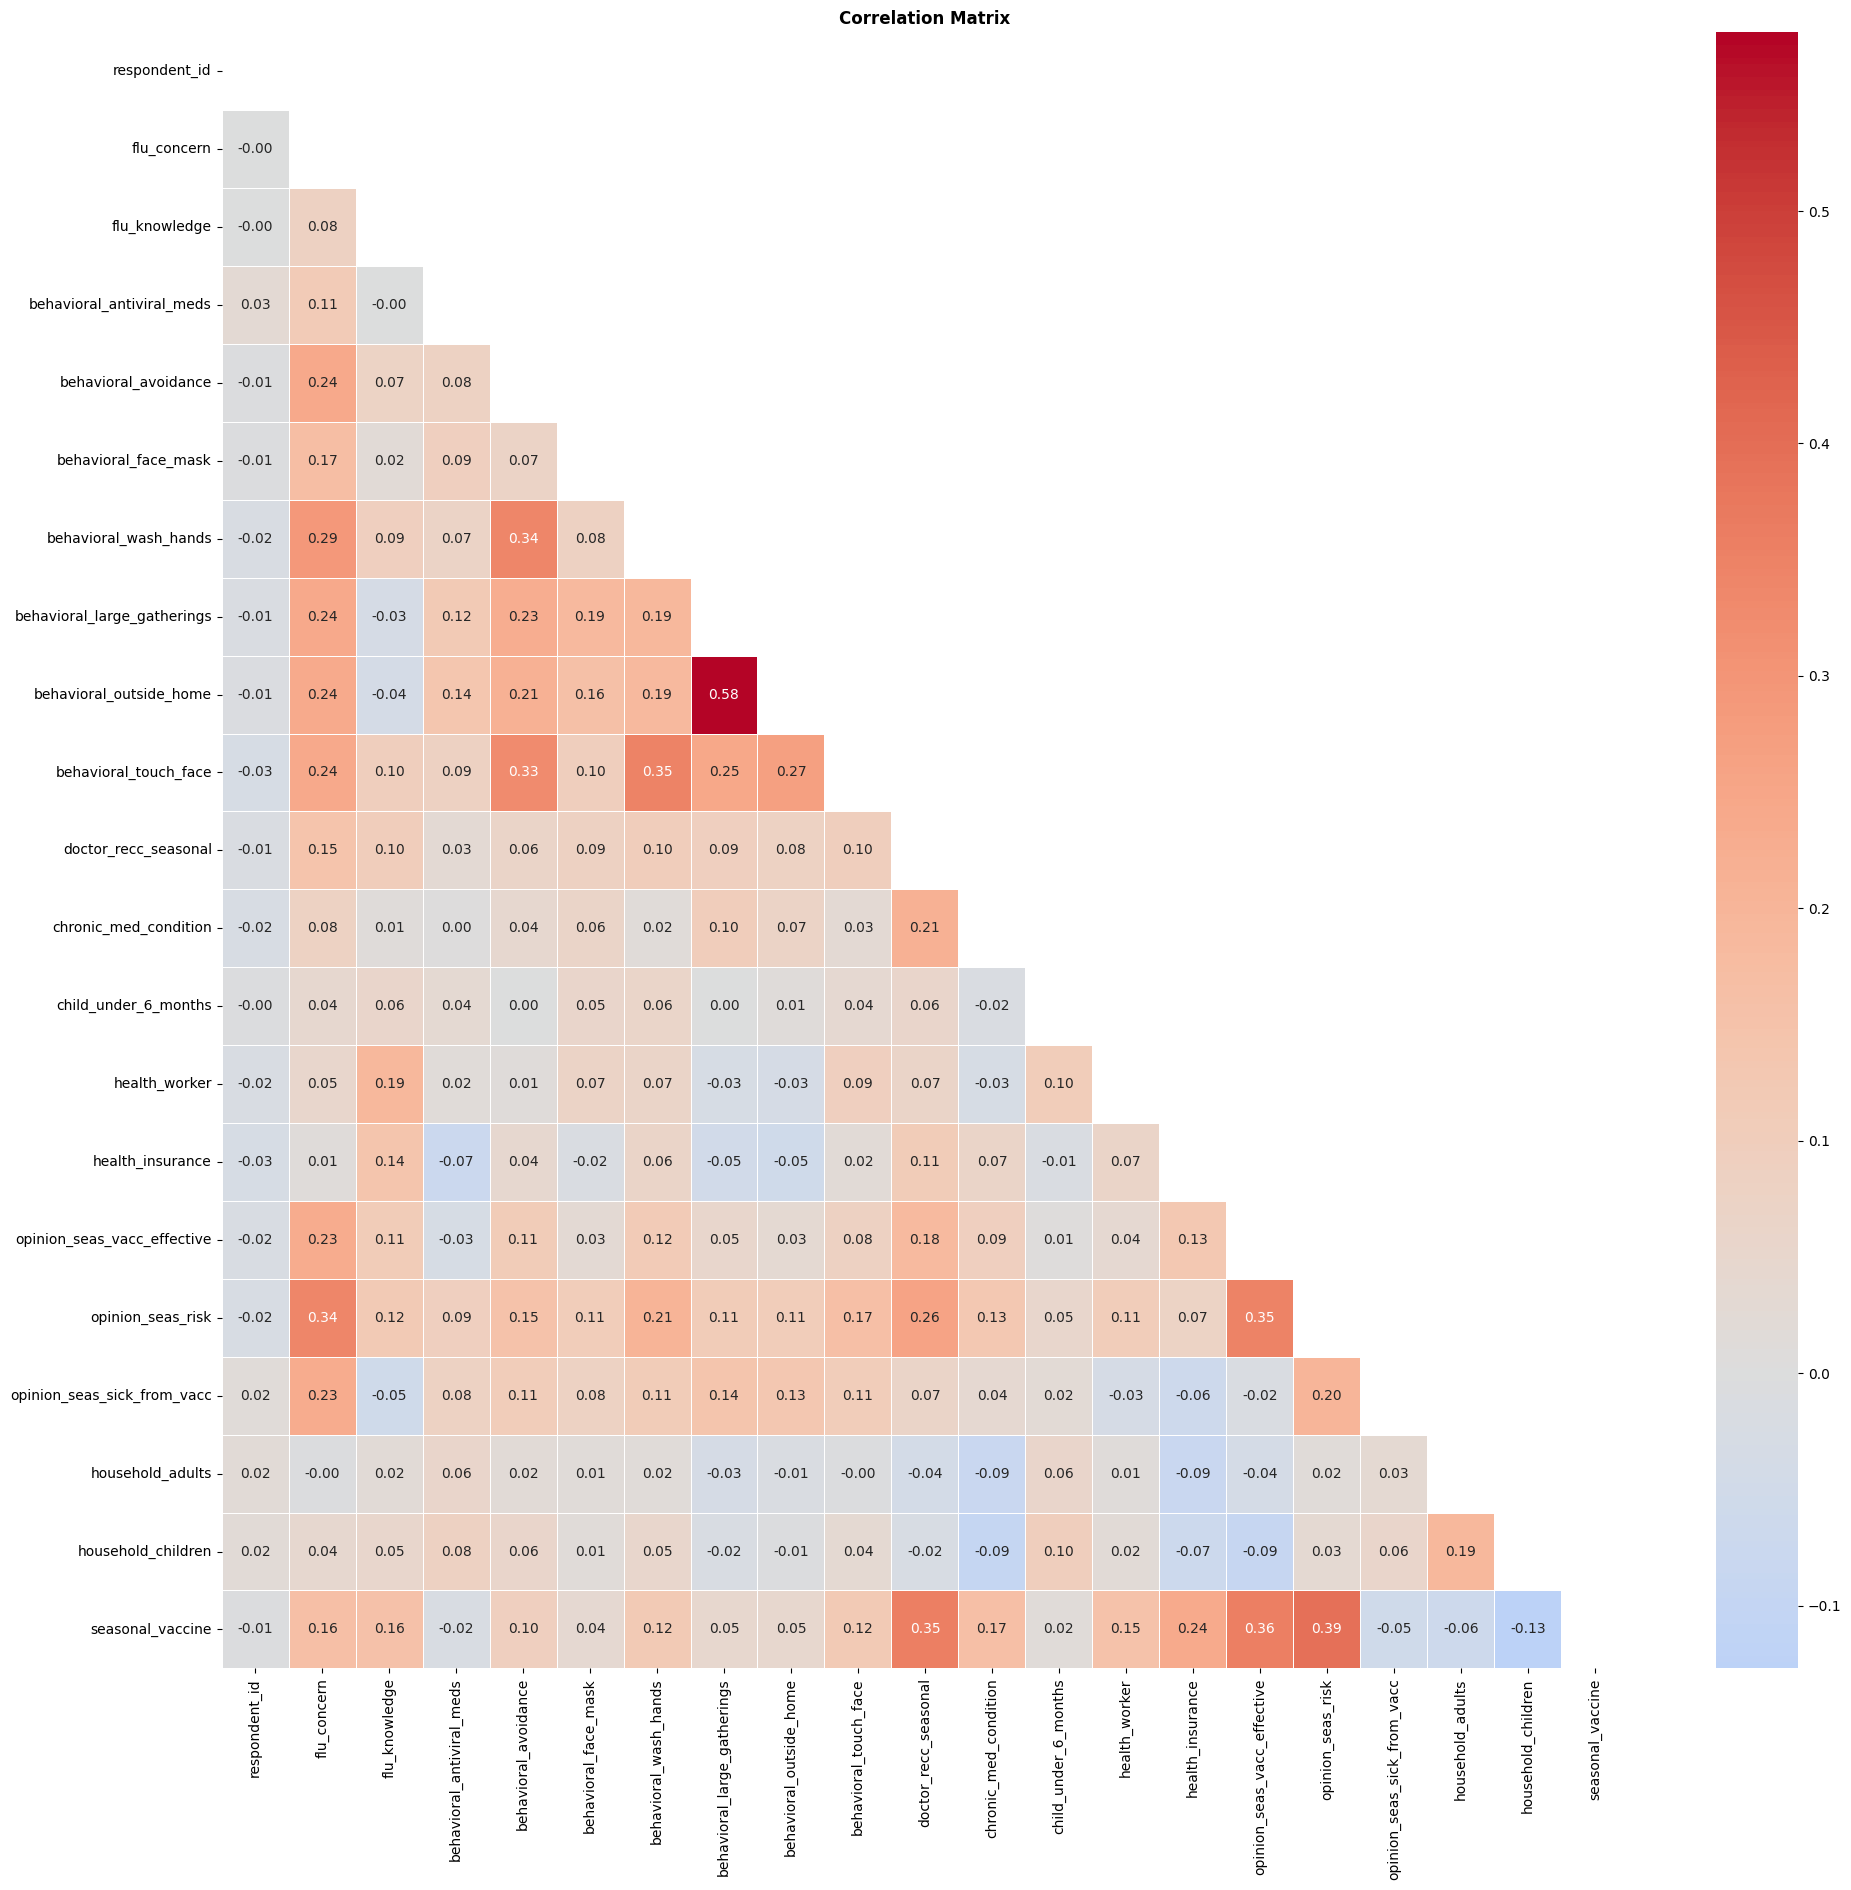

In [15]:
#  3.5 Correlation Heatmap (numeric features)
num_cols = df_train.select_dtypes(include=np.number).columns.tolist()
if Target_variable in num_cols:
    num_cols.remove(Target_variable )

if len(num_cols) > 1:
    corr = df_train[num_cols + [Target_variable ]].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(max(8, len(num_cols)), max(6, len(num_cols)-1)))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, linewidths=0.5)
    ax.set_title('Correlation Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()


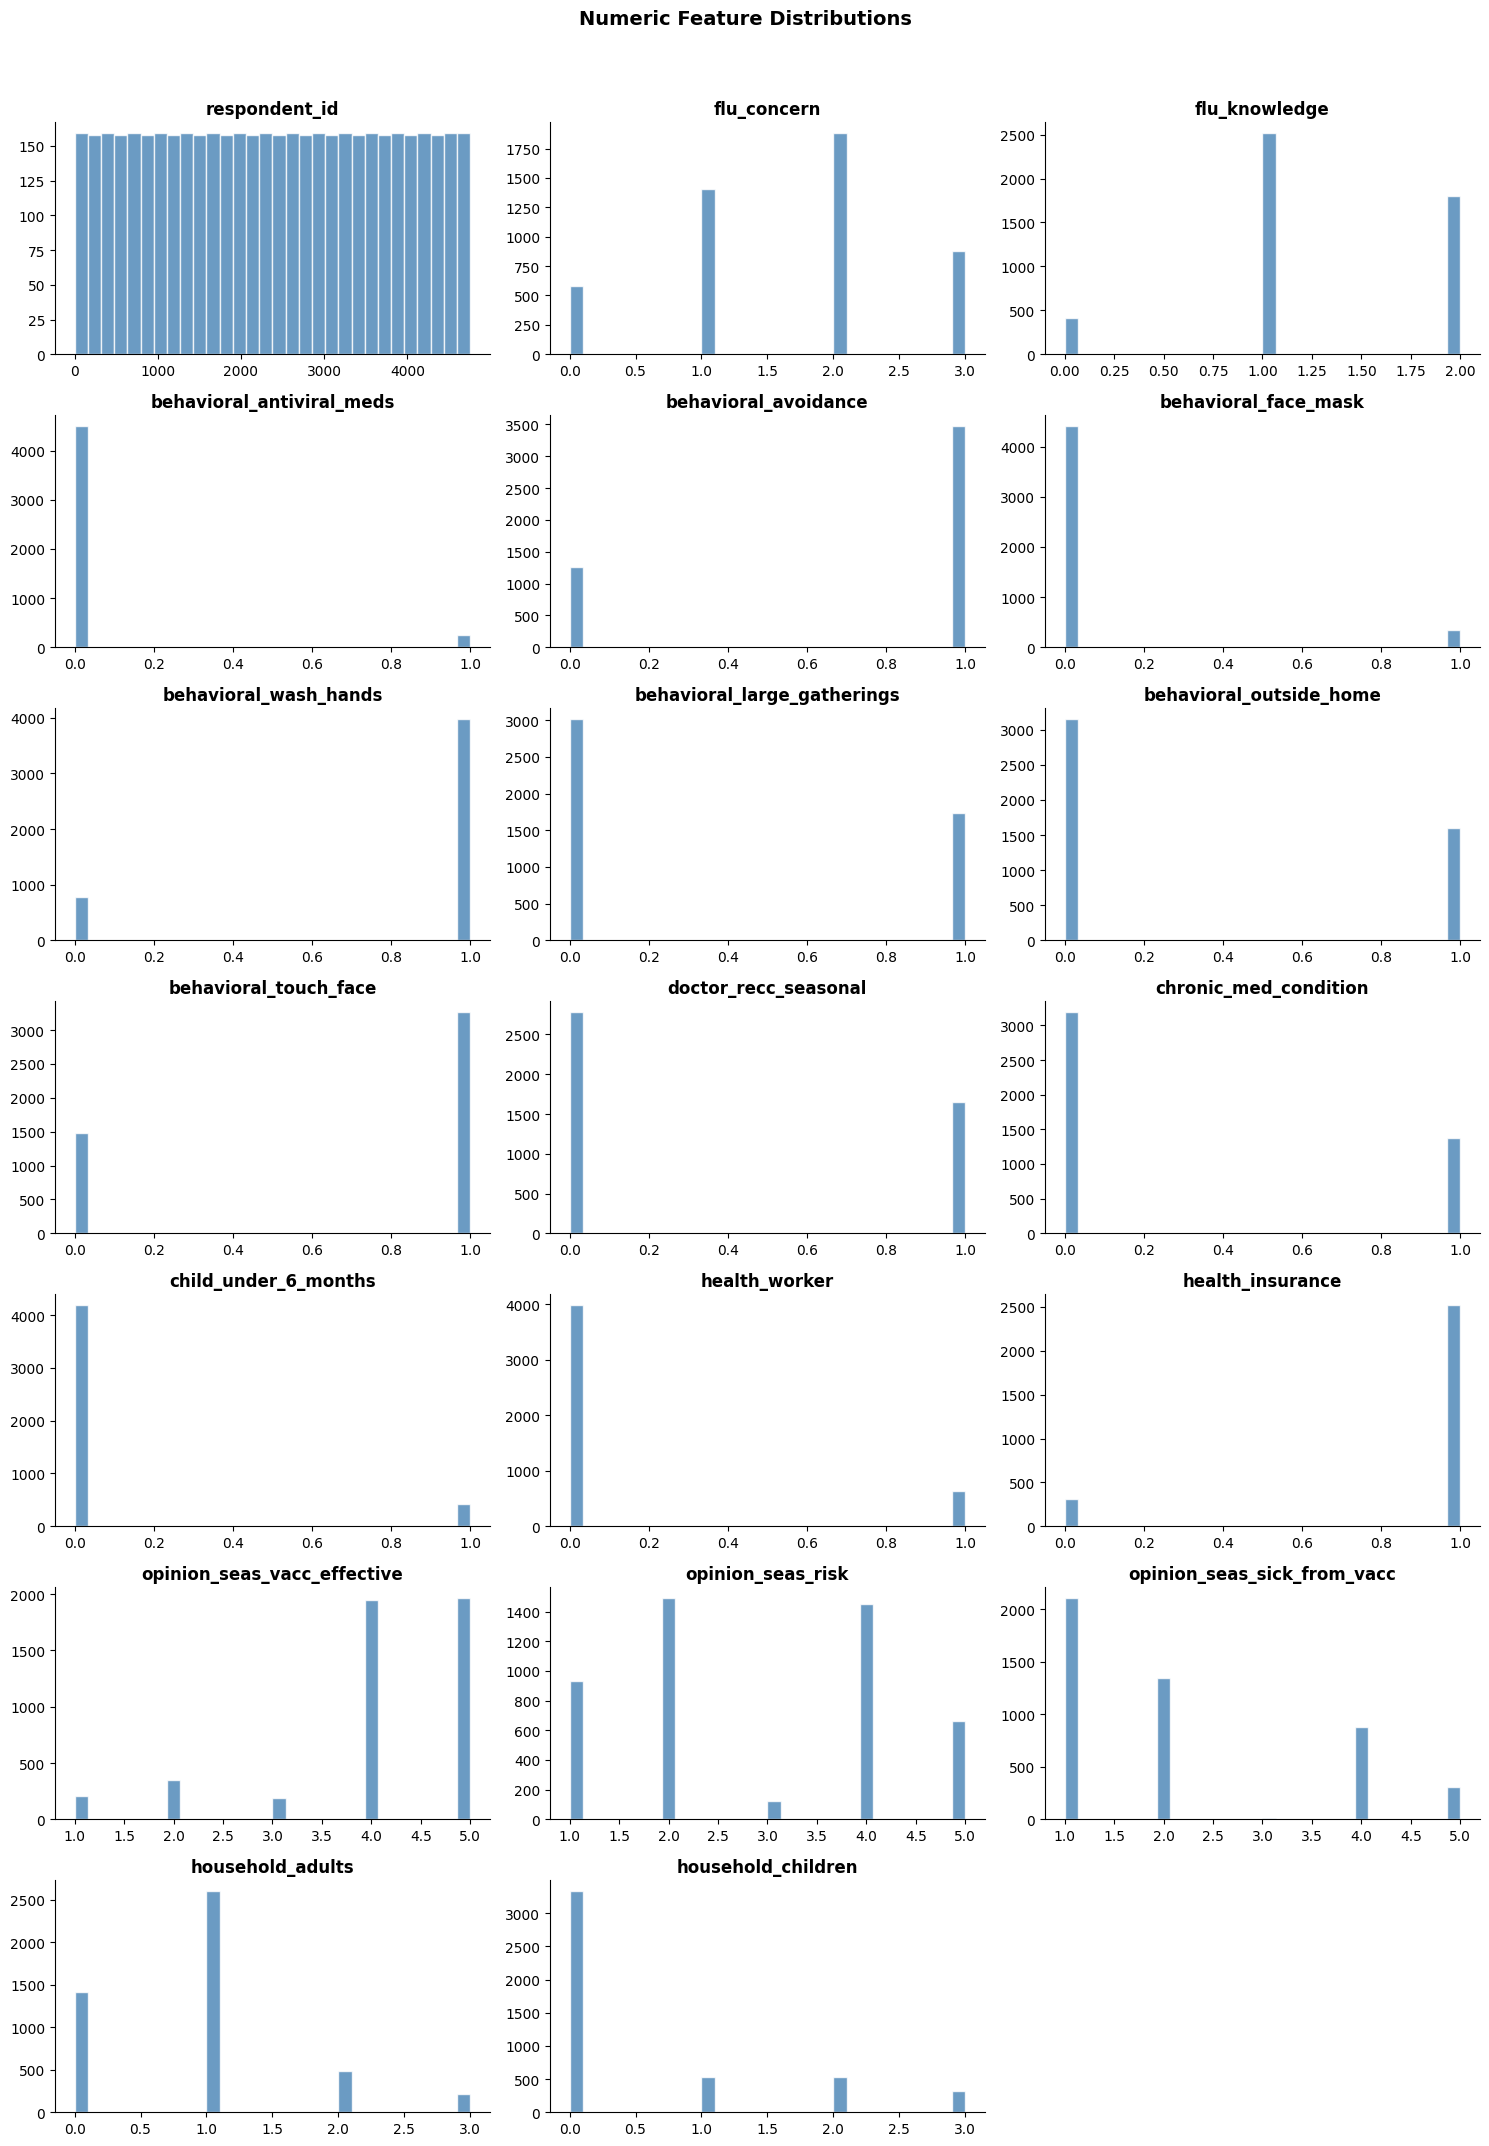

In [11]:
#  3.6 Numeric Feature Distributions
if len(num_cols) > 0:
    n_cols = 3
    n_rows = (len(num_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        axes[i].hist(df_train[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
        axes[i].set_title(col, fontweight='bold')
        axes[i].set_xlabel('')

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

Categorical columns: ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


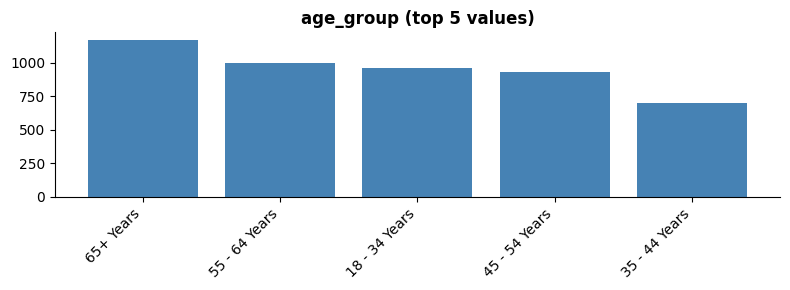

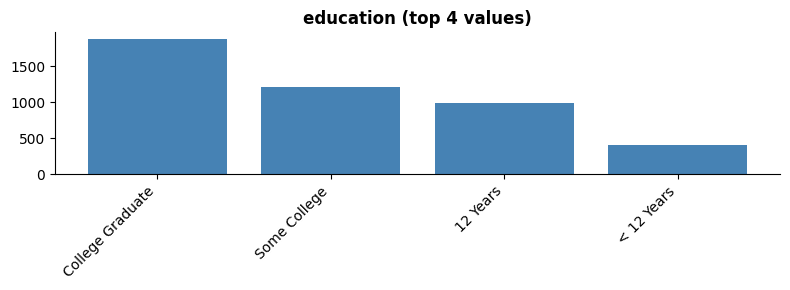

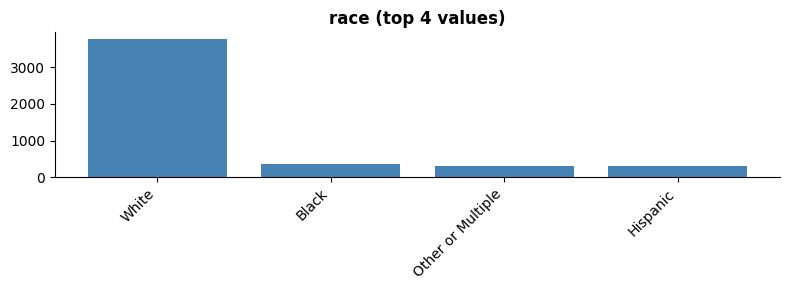

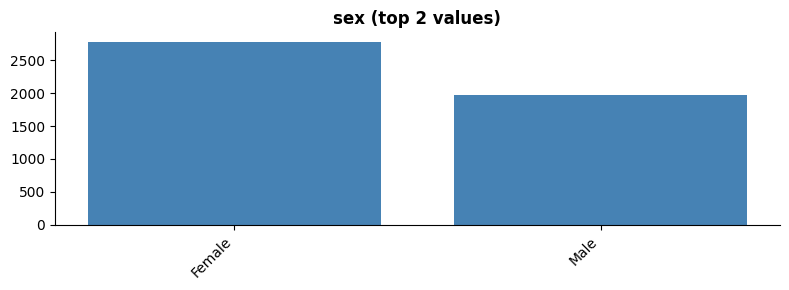

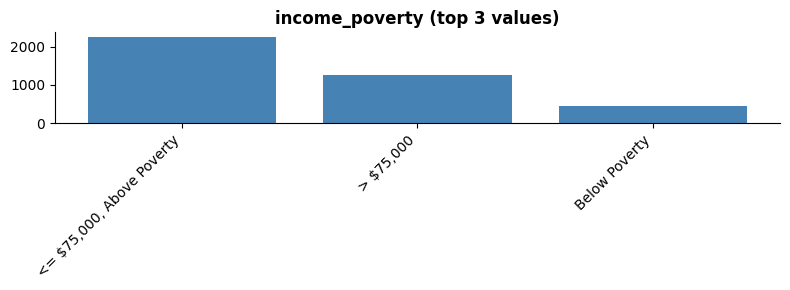

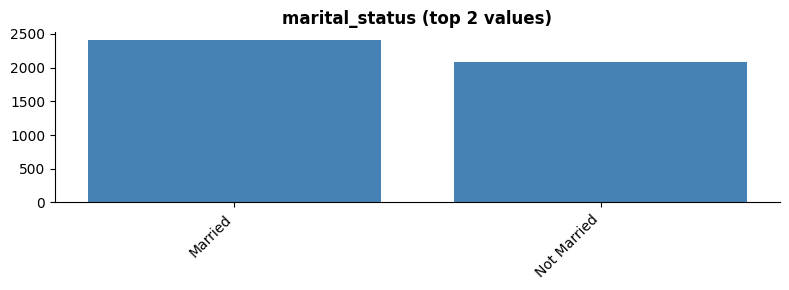

In [13]:
#  3.7 Categorical Feature Distributions
cat_cols = df_train.select_dtypes(include='object').columns.tolist()
if Target_variable in cat_cols:
    cat_cols.remove(Target_variable)

print(f'Categorical columns: {cat_cols}')

for col in cat_cols[:6]:
    fig, ax = plt.subplots(figsize=(8, 3))
    vc = df_train[col].value_counts().head(15)
    ax.bar(vc.index.astype(str), vc.values, color='steelblue')
    ax.set_title(f'{col} (top {len(vc)} values)', fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

---
# SECTION 4 — Feature Engineering

In [ ]:
#  4.1 Combine train and test


df_train['new_ratio'] = df_train['col_a'] / (df_train['col_b'] + 1)
df_train['interaction'] = df_train['col_a'] * df_train['col_b']
df_train['col_log'] = np.log1p(df_train['col_a'])
df_train['is_missing_col'] = df_train['col'].isnull().astype(int)

print('Feature engineering complete.')
print(f'Train columns: {df_train.shape[1]}')

KeyError: 'col_a'

---
#  SECTION 5 — Preprocessing Pipeline

In [ ]:
#  5.1 Identify column types
ID_COL = 'id'
drop_cols = [Target_variable]
if ID_COL and ID_COL in df_train.columns:
    drop_cols.append(ID_COL)

X = df_train.drop(columns=drop_cols)
y = df_train[Target_variable]

X_test_final = df_test.drop(columns=[c for c in drop_cols if c in df_test.columns and c != Target_variable])

num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(include='object').columns.tolist()

print(f'Numeric features ({len(num_features)}): {num_features}')
print(f'Categorical features ({len(cat_features)}): {cat_features}')

Numeric features (20): ['respondent_id', 'flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults', 'household_children']
Categorical features (10): ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


In [ ]:
#  5.2 Build Preprocessor
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
], remainder='drop')

#  5.3 Train / Validation Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y if y.nunique() < 15 else None
)

print(f'X_train: {X_train.shape}  |  X_val: {X_val.shape}')

X_train: (3804, 30)  |  X_val: (952, 30)


---
#  SECTION 6 — Model Training & Comparison


In [ ]:
#  6.1 Define models

TASK = 'classification'
SCORING = 'roc_auc'

models = {
    'Logistic Regression': Pipeline([('pre', preprocessor), ('model', LogisticRegression(max_iter=1000, random_state=42))]),
    'Random Forest':       Pipeline([('pre', preprocessor), ('model', RandomForestClassifier(n_estimators=200, random_state=42))]),
    'XGBoost':             Pipeline([('pre', preprocessor), ('model', XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=42, eval_metric='logloss'))]),
    'LightGBM':            Pipeline([('pre', preprocessor), ('model', LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1))]),
    'Gradient Boosting':   Pipeline([('pre', preprocessor), ('model', GradientBoostingClassifier(n_estimators=200, random_state=42))]),
}

print(f'Task: {TASK}  |  Scoring: {SCORING}')
print(f'Models to compare: {list(models.keys())}')

Task: classification  |  Scoring: roc_auc
Models to compare: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'Gradient Boosting']


In [ ]:
#  6.2 Cross-Validation Comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) if TASK == 'classification' \
     else KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

print(f'Running 5-fold cross-validation...\n')
print(f'{"Model":<25} {"CV Mean":>10} {"CV Std":>10}')
print('-' * 48)

for name, pipe in models.items():
    scores = cross_val_score(pipe, X, y, cv=cv, scoring=SCORING, n_jobs=-1)
    results[name] = {'mean': scores.mean(), 'std': scores.std(), 'scores': scores}
    print(f'{name:<25} {scores.mean():>10.4f} {scores.std():>10.4f}')

best_model_name = max(results, key=lambda x: results[x]['mean'])
print(f'\n Best model: {best_model_name} ({results[best_model_name]["mean"]:.4f})')

In [ ]:
# ── 6.3 Visualise Model Comparison ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

names = list(results.keys())
means = [results[n]['mean'] for n in names]
stds  = [results[n]['std']  for n in names]
colors = ['gold' if n == best_model_name else 'steelblue' for n in names]

bars = ax.barh(names, means, xerr=stds, color=colors, edgecolor='white', capsize=4)
ax.set_xlabel(f'CV Score ({SCORING})', fontweight='bold')
ax.set_title('Model Comparison — Cross-Validation Scores', fontweight='bold')

for bar, mean in zip(bars, means):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
#  6.4 Fit best model & evaluate on validation set
best_pipe = models[best_model_name]
best_pipe.fit(X_train, y_train)

if TASK == 'classification':
    y_pred = best_pipe.predict(X_val)
    y_prob = best_pipe.predict_proba(X_val)[:, 1] if hasattr(best_pipe, 'predict_proba') else None

    print(f'Validation Accuracy:  {accuracy_score(y_val, y_pred):.4f}')
    if y_prob is not None:
        print(f'Validation ROC-AUC:   {roc_auc_score(y_val, y_prob):.4f}')
    print(f'Validation F1:        {f1_score(y_val, y_pred, average="weighted"):.4f}')
    print()
    print('Classification Report:')
    print(classification_report(y_val, y_pred))

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(y_val, y_pred, ax=ax, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

else:
    y_pred = best_pipe.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae  = mean_absolute_error(y_val, y_pred)
    r2   = r2_score(y_val, y_pred)

    print(f'Validation RMSE: {rmse:.4f}')
    print(f'Validation MAE:  {mae:.4f}')
    print(f'Validation R²:   {r2:.4f}')

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(y_val, y_pred, alpha=0.5, color='steelblue')
    ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title('Actual vs Predicted', fontweight='bold')
    plt.tight_layout()
    plt.show()

---
# 🎛️ SECTION 7 — Hyperparameter Tuning (Best Model)

In [ ]:
# ── 7.1 Optuna Tuning for XGBoost (Classification) ───────────────────
# Adapt the param space for whichever model won in Section 6

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 9),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0, 1),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
    }

    model = XGBClassifier(**params, random_state=42, eval_metric='logloss', verbosity=0)  # or XGBRegressor
    pipe  = Pipeline([('pre', preprocessor), ('model', model)])
    score = cross_val_score(pipe, X, y, cv=5, scoring=SCORING, n_jobs=-1).mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)  # 🔁 Reduce n_trials if short on time

print(f'\n✅ Best trial score: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

In [ ]:
# ── 7.2 Retrain with best params ──────────────────────────────────────
tuned_model = XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss')  # 🔁 Swap model type
tuned_pipe  = Pipeline([('pre', preprocessor), ('model', tuned_model)])
tuned_pipe.fit(X, y)  # Train on FULL training data for final predictions

print('✅ Tuned model trained on full dataset.')

---
# 💡 SECTION 8 — Model Explainability (SHAP)

In [ ]:
# ── 8.1 Get processed feature names ───────────────────────────────────
X_transformed = preprocessor.fit_transform(X)

# Reconstruct feature names
try:
    cat_feature_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_features).tolist()
except:
    cat_feature_names = []

all_feature_names = num_features + cat_feature_names
print(f'Total features after encoding: {len(all_feature_names)}')

In [ ]:
# ── 8.2 SHAP Summary Plot ─────────────────────────────────────────────
# Use the preprocessed data and just the model (not the pipeline)
inner_model = tuned_pipe.named_steps['model']
X_transformed_df = pd.DataFrame(X_transformed, columns=all_feature_names)

explainer = shap.TreeExplainer(inner_model)
shap_values = explainer.shap_values(X_transformed_df)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_transformed_df, plot_type='bar', show=False)
plt.title('Feature Importance (SHAP)', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── 8.3 SHAP Beeswarm (direction of impact) ───────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_transformed_df, show=False)
plt.title('SHAP Feature Impact (direction & magnitude)', fontweight='bold')
plt.tight_layout()
plt.show()

---
# 📤 SECTION 9 — Generate Submission Files (Top 5)

In [ ]:
# ── 9.1 Generate predictions for all models ───────────────────────────
# Sort models by CV score
ranked_models = sorted(results.items(), key=lambda x: x[1]['mean'], reverse=True)
print('Model ranking (best to worst):')
for i, (name, res) in enumerate(ranked_models, 1):
    print(f'  {i}. {name}: {res["mean"]:.4f} ± {res["std"]:.4f}')

In [ ]:
# ── 9.2 Save submission files ─────────────────────────────────────────
submission_files = []

for rank, (name, _) in enumerate(ranked_models[:5], 1):
    pipe = models[name]
    pipe.fit(X, y)  # retrain on full training data

    if TASK == 'classification':
        # Use probabilities if available, else hard labels
        if hasattr(pipe, 'predict_proba'):
            preds = pipe.predict_proba(X_test_final)[:, 1]
        else:
            preds = pipe.predict(X_test_final)
    else:
        preds = pipe.predict(X_test_final)

    submission = pd.DataFrame({
        ID_COL if ID_COL else 'id': df_test[ID_COL] if ID_COL and ID_COL in df_test.columns else range(len(df_test)),
        TARGET: preds
    })

    filename = f'submission_rank{rank}_{name.replace(" ", "_").lower()}.csv'
    submission.to_csv(filename, index=False)
    submission_files.append(filename)
    print(f'✅ Saved: {filename}  |  Shape: {submission.shape}')

# Also save tuned model as submission 1 override
tuned_preds = tuned_pipe.predict_proba(X_test_final)[:, 1] if TASK == 'classification' else tuned_pipe.predict(X_test_final)
tuned_submission = pd.DataFrame({
    ID_COL if ID_COL else 'id': df_test[ID_COL] if ID_COL and ID_COL in df_test.columns else range(len(df_test)),
    TARGET: tuned_preds
})
tuned_submission.to_csv('submission_rank1_tuned_best.csv', index=False)
print('✅ Saved: submission_rank1_tuned_best.csv (tuned best model)')

In [ ]:
# ── 9.3 Preview top submission ────────────────────────────────────────
print('Preview of top submission:')
display(tuned_submission.head(10))
print(f'\nShape: {tuned_submission.shape}')
print(f'Prediction range: {tuned_submission[TARGET].min():.4f} — {tuned_submission[TARGET].max():.4f}')

---
# 📊 SECTION 10 — Results Summary (for Presentation)

In [ ]:
# ── 10.1 Final Results Table ──────────────────────────────────────────
print('='*65)
print('FINAL MODEL SUBMISSION ORDER')
print('='*65)
print(f'{"Rank":<6} {"Model":<30} {"CV Score":>12} {"Std":>8}')
print('-'*65)

print(f'{1:<6} {"Tuned " + best_model_name:<30} {study.best_value:>12.4f} {"(tuned)":>8}')
for rank, (name, res) in enumerate(ranked_models[:5], 2):
    print(f'{rank:<6} {name:<30} {res["mean"]:>12.4f} {res["std"]:>8.4f}')

print('='*65)
print(f'\nScoring metric: {SCORING}')
print(f'Task type:      {TASK}')

---
# 🎤 PRESENTATION NOTES

## Slide Structure (suggested)
1. **Problem Statement** — What are we predicting and why does it matter?
2. **Data Overview** — Key stats, missing values, class balance
3. **Key EDA Findings** — 2–3 most interesting charts
4. **Feature Engineering** — What new features did you create and why?
5. **Model Comparison** — CV score chart (Section 6.3)
6. **Best Model Results** — Confusion matrix / Actual vs Predicted
7. **Feature Importance** — SHAP plot and what it means
8. **Submission Strategy** — Why you ranked the models the way you did
9. **What We'd Do Next** — With more time/data/compute

## Critical Analysis Points to Address
- Why did the best model win?
- Are you overfitting? (CV std is a clue)
- Which features drove predictions the most?
- What are the risks of your model in production?

---
## 📝 Team Notes
*(Add your notes here throughout the hackathon)*
-
-
-